<a href="https://colab.research.google.com/github/ManuelRomero2025/CienciasdeDatos1/blob/main/LimpezaV1_Modelo__dirty_cafe_sales_V2_20252.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpieza de Datos, EDA, Inferencia Estadística y Machine Learning  
## Base: `dirty_cafe_sales.csv`

Este notebook integra en un solo flujo todas las fases desarrolladas previamente:

1. Inspección de variables y diagnóstico inicial  
2. Limpieza de datos por fases  
3. Análisis Exploratorio de Datos (EDA)  
4. Tests estadísticos  
5. Fase de nivel experto  
6. Conexión con modelos predictivos de Machine Learning  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, accuracy_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Fase 0. Carga de la base

In [ ]:
# Asegúrate de haber montado Google Drive previamente
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Leer el archivo desde Drive
df = pd.read_csv('/content/drive/MyDrive/CienciasDatos2025/Limpiezadedatos2026/dirty_cafe_sales.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fase 1. Inspección de variables, tipo de variable, escala de medición y limpieza requerida

| Variable         | Tipo de Variable            | Tipo de Medición | Descripción Técnica                                                               | Problemas Identificados                                  | Tipo de Limpieza Requerida                                                            |
| ---------------- | --------------------------- | ---------------- | --------------------------------------------------------------------------------- | -------------------------------------------------------- | ------------------------------------------------------------------------------------- |
| Transaction ID   | Cualitativa (Identificador) | Nominal          | Identificador único de cada transacción. No tiene significado numérico analítico. | Posibles valores duplicados o inconsistentes             | Validación de unicidad, eliminación de duplicados, estandarización de formato         |
| Item             | Cualitativa                 | Nominal          | Producto vendido en la cafetería.                                                 | Valores como `UNKNOWN`, errores tipográficos             | Normalización de categorías, imputación o eliminación de valores desconocidos         |
| Quantity         | Cuantitativa discreta       | Razón            | Cantidad de productos comprados por transacción.                                  | Valores no numéricos, negativos o `ERROR`                | Conversión a numérico, imputación, detección de outliers, validación de dominio (>0)  |
| Price Per Unit   | Cuantitativa continua       | Razón            | Precio unitario del producto.                                                     | Valores no numéricos, inconsistencias, posibles outliers | Conversión a numérico, tratamiento de outliers, imputación                            |
| Total Spent      | Cuantitativa continua       | Razón            | Valor total de la transacción (Quantity × Price).                                 | Inconsistencias con otras variables, valores erróneos    | Re-cálculo de la variable, validación cruzada, imputación o corrección                |
| Payment Method   | Cualitativa                 | Nominal          | Método de pago utilizado (efectivo, tarjeta, etc.).                               | Valores `UNKNOWN`, inconsistencias en categorías         | Estandarización de categorías, imputación o eliminación de registros                  |
| Location         | Cualitativa                 | Nominal          | Ubicación de la transacción.                                                      | Valores inconsistentes o mal escritos                    | Normalización de texto, corrección de categorías, imputación si aplica                |
| Transaction Date | Cuantitativa (Temporal)     | Intervalo        | Fecha en que se realizó la transacción.                                           | Formato inconsistente, valores inválidos                 | Conversión a formato fecha, validación de rangos, imputación o eliminación de errores |


## Fase 2. Diagnóstico inicial de calidad de datos

In [ ]:
diagnostico = pd.DataFrame({
    "Variable": df.columns,
    "Tipo inicial": df.dtypes.values,
    "Nulos": df.isna().sum().values,
    "UNKNOWN": [(df[col].astype(str).str.upper() == "UNKNOWN").sum() for col in df.columns],
    "ERROR": [(df[col].astype(str).str.upper() == "ERROR").sum() for col in df.columns]
})
diagnostico

,Variable,Tipo inicial,Nulos,UNKNOWN,ERROR
0,Transaction ID,object,0,0,0
1,Item,object,333,344,292
2,Quantity,object,138,171,170
3,Price Per Unit,object,179,164,190
4,Total Spent,object,173,165,164
5,Payment Method,object,2579,293,306
6,Location,object,3265,338,358
7,Transaction Date,object,159,159,142


In [ ]:
print("Número de filas duplicadas completas:", df.duplicated().sum())
print("Número de Transaction ID duplicados:", df["Transaction ID"].duplicated().sum())

Número de filas duplicadas completas: 0
Número de Transaction ID duplicados: 0


## Fase 3. Limpieza de datos por etapas

In [ ]:
df_clean = df.copy()

# 3.1 Reemplazar etiquetas inválidas
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace(["UNKNOWN", "ERROR"], np.nan)

# 3.2 Conversión de tipos
df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors="coerce")
df_clean["Price Per Unit"] = pd.to_numeric(df_clean["Price Per Unit"], errors="coerce")
df_clean["Total Spent"] = pd.to_numeric(df_clean["Total Spent"], errors="coerce")
df_clean["Transaction Date"] = pd.to_datetime(df_clean["Transaction Date"], errors="coerce")

# 3.3 Eliminar duplicados completos
df_clean = df_clean.drop_duplicates()

# 3.4 Imputación de variables categóricas
for col in ["Item", "Payment Method", "Location"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 3.5 Imputación de variables numéricas
mediana_quantity = df_clean["Quantity"].median()
df_clean["Quantity"] = df_clean["Quantity"].fillna(mediana_quantity)
df_clean["Quantity"] = df_clean["Quantity"].round().astype(int)
df_clean.loc[df_clean["Quantity"] <= 0, "Quantity"] = int(round(mediana_quantity))

mediana_precio = df_clean["Price Per Unit"].median()
df_clean["Price Per Unit"] = df_clean["Price Per Unit"].fillna(mediana_precio)
df_clean.loc[df_clean["Price Per Unit"] <= 0, "Price Per Unit"] = mediana_precio

# 3.6 Imputación de fecha
fechas_validas = df_clean["Transaction Date"].dropna().sort_values()
fecha_mediana = fechas_validas.iloc[len(fechas_validas)//2]
df_clean["Transaction Date"] = df_clean["Transaction Date"].fillna(fecha_mediana)

# 3.7 Validación lógica
df_clean["Total Spent"] = df_clean["Quantity"] * df_clean["Price Per Unit"]

print("Valores faltantes finales:")
print(df_clean.isna().sum())
print("\nTipos finales:")
print(df_clean.dtypes)
df_clean.head()

Valores faltantes finales:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Tipos finales:
Transaction ID              object
Item                        object
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
df_clean.to_csv("dirty_cafe_sales_clean.csv", index=False)
print("Archivo limpio exportado como dirty_cafe_sales_clean.csv")

Archivo limpio exportado como dirty_cafe_sales_clean.csv


## Fase 4. EDA: análisis univariado, bivariado y temporal

In [ ]:
numericas = ["Quantity", "Price Per Unit", "Total Spent"]
categoricas = ["Item", "Payment Method", "Location"]

resumen_numericas = df_clean[numericas].describe().T
resumen_numericas["skewness"] = df_clean[numericas].skew()
resumen_numericas["kurtosis"] = df_clean[numericas].kurtosis()
resumen_numericas

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Quantity,10000.0,3.02710,1.384614,1.0,2.0,3.0,4.0,5.0,-0.005339,-1.227709
Price Per Unit,10000.0,2.95265,1.243960,1.0,2.0,3.0,4.0,5.0,-0.001710,-1.052151
Total Spent,10000.0,8.94815,5.831191,1.0,4.0,8.0,12.0,25.0,0.797699,-0.101346


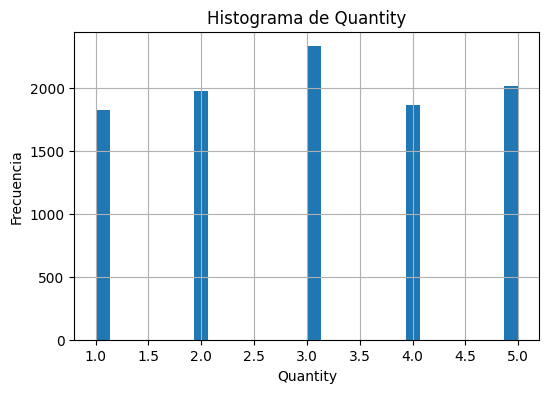

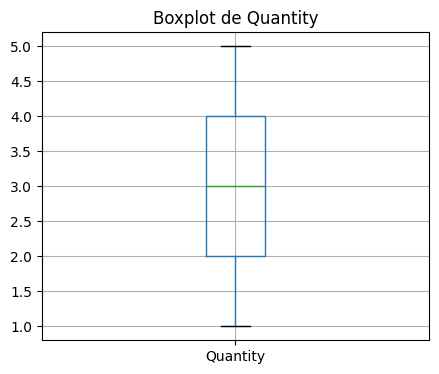

Interpretación automática para Quantity: distribución aproximadamente simétrica
--------------------------------------------------------------------------------


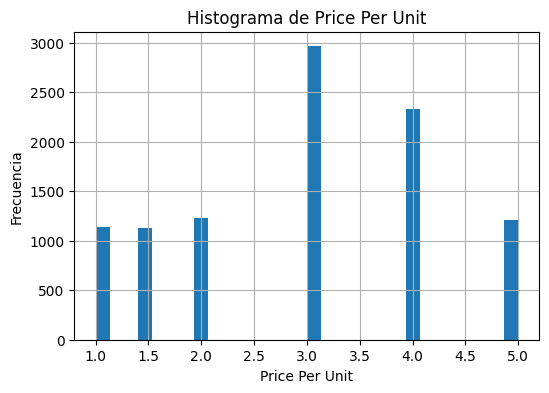

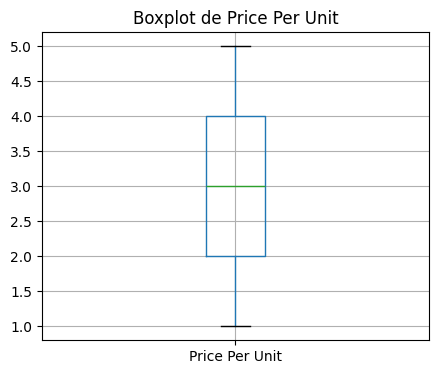

Interpretación automática para Price Per Unit: distribución aproximadamente simétrica
--------------------------------------------------------------------------------


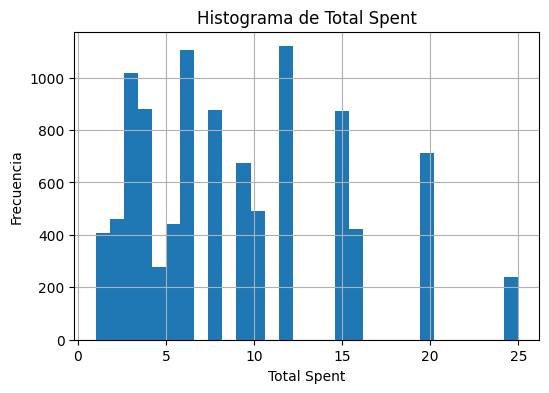

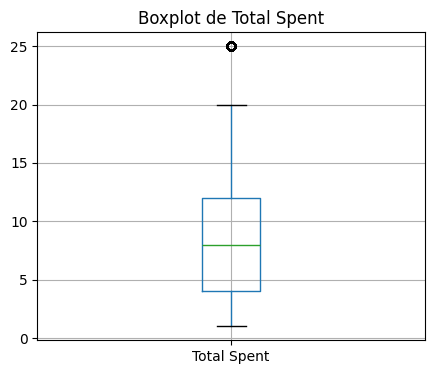

Interpretación automática para Total Spent: distribución moderadamente sesgada a la derecha
--------------------------------------------------------------------------------


In [ ]:
for col in numericas:
    plt.figure(figsize=(6,4))
    df_clean[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

    plt.figure(figsize=(5,4))
    df_clean.boxplot(column=col)
    plt.title(f"Boxplot de {col}")
    plt.show()

    skew = df_clean[col].skew()
    if skew > 1:
        interpretacion = "distribución fuertemente sesgada a la derecha"
    elif skew < -1:
        interpretacion = "distribución fuertemente sesgada a la izquierda"
    elif skew > 0.3:
        interpretacion = "distribución moderadamente sesgada a la derecha"
    elif skew < -0.3:
        interpretacion = "distribución moderadamente sesgada a la izquierda"
    else:
        interpretacion = "distribución aproximadamente simétrica"

    print(f"Interpretación automática para {col}: {interpretacion}")
    print("-"*80)


Frecuencias de Item:
Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


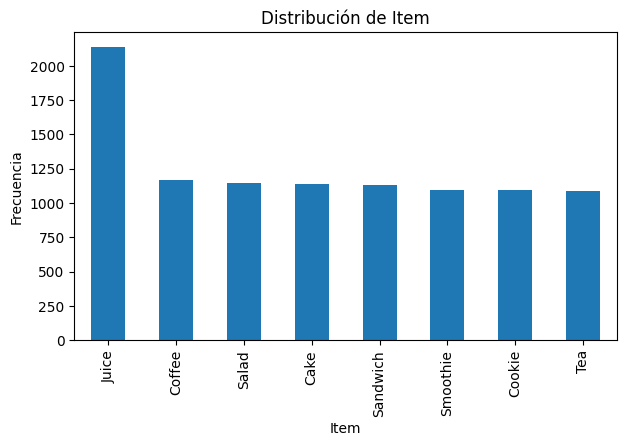

Interpretación automática: la categoría dominante en Item es 'Juice' con proporción aproximada de 21.40%.
--------------------------------------------------------------------------------

Frecuencias de Payment Method:
Payment Method
Digital Wallet    5469
Credit Card       2273
Cash              2258
Name: count, dtype: int64


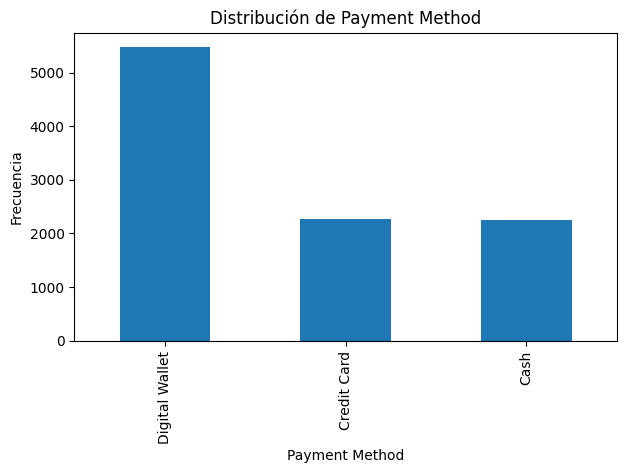

Interpretación automática: la categoría dominante en Payment Method es 'Digital Wallet' con proporción aproximada de 54.69%.
--------------------------------------------------------------------------------

Frecuencias de Location:
Location
Takeaway    6983
In-store    3017
Name: count, dtype: int64


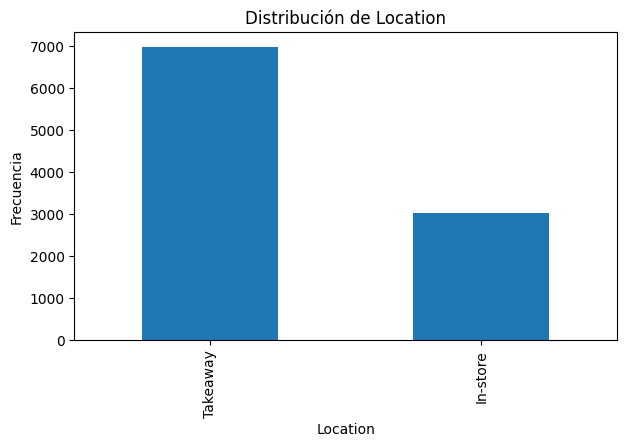

Interpretación automática: la categoría dominante en Location es 'Takeaway' con proporción aproximada de 69.83%.
--------------------------------------------------------------------------------


In [ ]:
for col in categoricas:
    frec = df_clean[col].value_counts(dropna=False)
    print(f"\nFrecuencias de {col}:")
    print(frec)

    plt.figure(figsize=(7,4))
    frec.plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

    categoria_top = frec.idxmax()
    proporcion = frec.iloc[0] / frec.sum()
    print(f"Interpretación automática: la categoría dominante en {col} es '{categoria_top}' con proporción aproximada de {proporcion:.2%}.")
    print("-"*80)

In [ ]:
corr = df_clean[numericas].corr()
corr

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.005913,0.707507
Price Per Unit,0.005913,1.000000,0.646076
Total Spent,0.707507,0.646076,1.000000


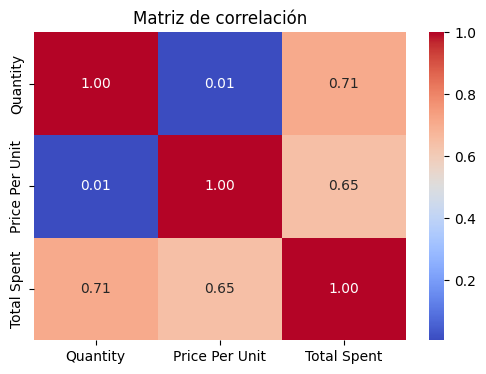

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

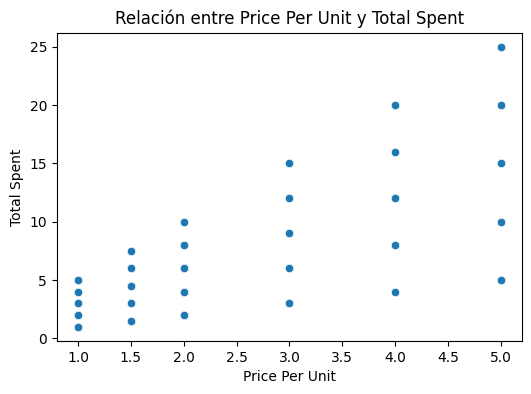

Interpretación automática: se espera una relación positiva, dado que el gasto total depende del precio unitario y de la cantidad comprada.


In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x="Price Per Unit", y="Total Spent")
plt.title("Relación entre Price Per Unit y Total Spent")
plt.show()

print("Interpretación automática: se espera una relación positiva, dado que el gasto total depende del precio unitario y de la cantidad comprada.")

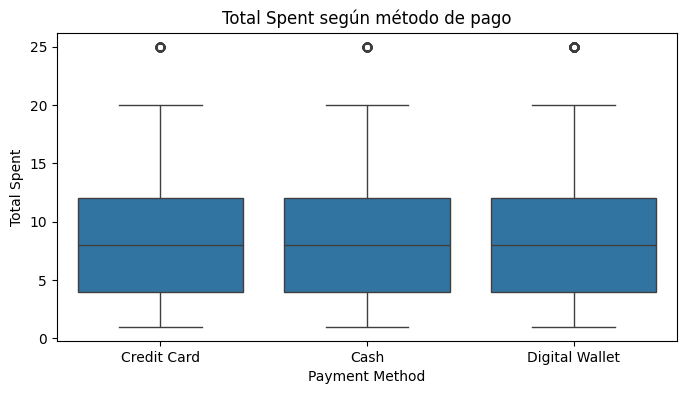

Interpretación automática: este gráfico permite comparar visualmente la dispersión y la mediana del gasto entre los métodos de pago.


In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x="Payment Method", y="Total Spent")
plt.title("Total Spent según método de pago")
plt.xticks(rotation=0)
plt.show()

print("Interpretación automática: este gráfico permite comparar visualmente la dispersión y la mediana del gasto entre los métodos de pago.")

In [ ]:
tabla_pago_location = pd.crosstab(df_clean["Payment Method"], df_clean["Location"])
tabla_pago_location

Location,In-store,Takeaway
Payment Method,,
Cash,702,1556
Credit Card,681,1592
Digital Wallet,1634,3835


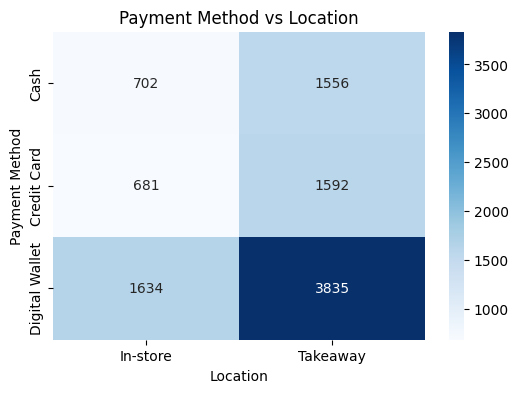

Interpretación automática: la tabla de contingencia permite evaluar si ciertas ubicaciones presentan mayor preferencia por un método de pago específico.


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(tabla_pago_location, annot=True, fmt="d", cmap="Blues")
plt.title("Payment Method vs Location")
plt.show()

print("Interpretación automática: la tabla de contingencia permite evaluar si ciertas ubicaciones presentan mayor preferencia por un método de pago específico.")

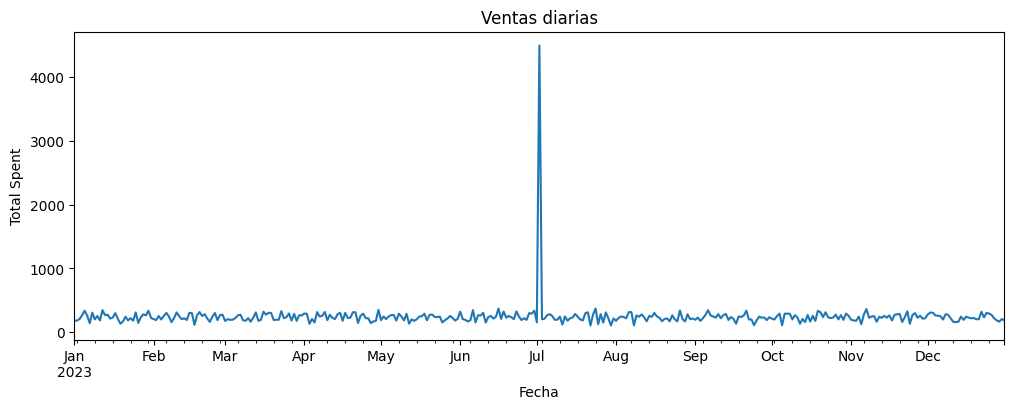

Interpretación automática: el gráfico temporal permite identificar picos, valles y posible estacionalidad en las ventas.


In [ ]:
ventas_diarias = df_clean.groupby("Transaction Date")["Total Spent"].sum().sort_index()

plt.figure(figsize=(12,4))
ventas_diarias.plot()
plt.title("Ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Total Spent")
plt.show()

print("Interpretación automática: el gráfico temporal permite identificar picos, valles y posible estacionalidad en las ventas.")

## Fase 5. Tests estadísticos

In [ ]:
print("Shapiro-Wilk (sobre muestra de máximo 500 observaciones por variable):")
for col in numericas:
    muestra = df_clean[col].sample(min(500, len(df_clean)), random_state=42)
    stat, p = stats.shapiro(muestra)
    conclusion = "No se rechaza normalidad" if p > 0.05 else "Se rechaza normalidad"
    print(f"{col}: estadístico={stat:.4f}, p-valor={p:.6f} -> {conclusion}")

Shapiro-Wilk (sobre muestra de máximo 500 observaciones por variable):
Quantity: estadístico=0.8919, p-valor=0.000000 -> Se rechaza normalidad
Price Per Unit: estadístico=0.9100, p-valor=0.000000 -> Se rechaza normalidad
Total Spent: estadístico=0.9195, p-valor=0.000000 -> Se rechaza normalidad


In [ ]:
grupos_total = [grupo["Total Spent"].values for _, grupo in df_clean.groupby("Payment Method")]

stat_anova, p_anova = stats.f_oneway(*grupos_total)
print(f"ANOVA: estadístico={stat_anova:.4f}, p-valor={p_anova:.6f}")

if p_anova < 0.05:
    print("Conclusión: existen diferencias estadísticamente significativas entre los métodos de pago.")
else:
    print("Conclusión: no se evidencian diferencias estadísticamente significativas entre los métodos de pago.")

ANOVA: estadístico=1.0874, p-valor=0.337116
Conclusión: no se evidencian diferencias estadísticamente significativas entre los métodos de pago.


In [ ]:
stat_levene, p_levene = stats.levene(*grupos_total)
print(f"Levene: estadístico={stat_levene:.4f}, p-valor={p_levene:.6f}")

if p_levene < 0.05:
    print("Conclusión: se rechaza homogeneidad de varianzas.")
else:
    print("Conclusión: no se rechaza homogeneidad de varianzas.")

Levene: estadístico=0.9951, p-valor=0.369737
Conclusión: no se rechaza homogeneidad de varianzas.


In [ ]:
stat_kw, p_kw = stats.kruskal(*grupos_total)
print(f"Kruskal-Wallis: estadístico={stat_kw:.4f}, p-valor={p_kw:.6f}")

if p_kw < 0.05:
    print("Conclusión: existen diferencias entre grupos bajo un enfoque no paramétrico.")
else:
    print("Conclusión: no se evidencian diferencias entre grupos bajo un enfoque no paramétrico.")

Kruskal-Wallis: estadístico=1.9150, p-valor=0.383858
Conclusión: no se evidencian diferencias entre grupos bajo un enfoque no paramétrico.


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df_clean["Total Spent"],
    groups=df_clean["Payment Method"],
    alpha=0.05
)
print(tukey)

In [ ]:
chi2, p_chi, dof, expected = chi2_contingency(tabla_pago_location)
print(f"Chi-cuadrado: estadístico={chi2:.4f}, p-valor={p_chi:.6f}, gl={dof}")

if p_chi < 0.05:
    print("Conclusión: existe asociación entre Payment Method y Location.")
else:
    print("Conclusión: no existe evidencia suficiente de asociación entre Payment Method y Location.")

Chi-cuadrado: estadístico=1.1756, p-valor=0.555549, gl=2
Conclusión: no existe evidencia suficiente de asociación entre Payment Method y Location.


## Fase 6. Nivel experto: tamaño del efecto, residuos tipificados y lectura avanzada

In [ ]:
media_global = df_clean["Total Spent"].mean()
ss_between = sum(len(g) * (g["Total Spent"].mean() - media_global)**2 for _, g in df_clean.groupby("Payment Method"))
ss_total = sum((df_clean["Total Spent"] - media_global)**2)
eta_sq = ss_between / ss_total

print(f"Eta cuadrado (η²): {eta_sq:.6f}")

if eta_sq < 0.01:
    print("Interpretación: tamaño del efecto prácticamente nulo.")
elif eta_sq < 0.06:
    print("Interpretación: tamaño del efecto pequeño.")
elif eta_sq < 0.14:
    print("Interpretación: tamaño del efecto moderado.")
else:
    print("Interpretación: tamaño del efecto grande.")

Eta cuadrado (η²): 0.000218
Interpretación: tamaño del efecto prácticamente nulo.


In [ ]:
residuos_tipificados = (tabla_pago_location - expected) / np.sqrt(expected)
residuos_tipificados

Location,In-store,Takeaway
Payment Method,,
Cash,0.795439,-0.522846
Credit Card,-0.181925,0.119580
Digital Wallet,-0.393827,0.258864


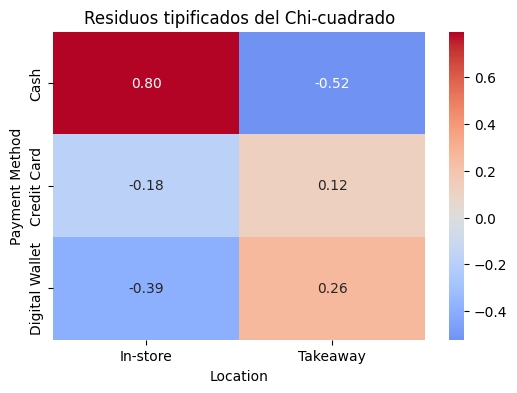

Interpretación automática: residuos tipificados con magnitud cercana o superior a 2 sugieren celdas con mayor contribución a la asociación.


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(residuos_tipificados, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Residuos tipificados del Chi-cuadrado")
plt.show()

print("Interpretación automática: residuos tipificados con magnitud cercana o superior a 2 sugieren celdas con mayor contribución a la asociación.")

## Fase 7. Machine Learning

### 7.1 Regresión pedagógica

Se incluye una fase de regresión para conectar el EDA con ML.  
Sin embargo, debe advertirse que `Total Spent` fue recalculada como `Quantity × Price Per Unit`, por lo que predecirla usando esas mismas variables produce un problema de **fuga de información (data leakage)** y un desempeño artificialmente alto.

Por ello, esta parte se deja como ejercicio pedagógico y no como modelo de negocio final.


In [ ]:
X_reg = df_clean[["Quantity", "Price Per Unit"]]
y_reg = df_clean["Total Spent"]

pre_reg = ColumnTransformer([
    ("num", StandardScaler(), ["Quantity", "Price Per Unit"])
])

pipe_lr = Pipeline([
    ("prep", pre_reg),
    ("model", LinearRegression())
])

pipe_rf_reg = Pipeline([
    ("prep", pre_reg),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(pipe_lr, X_reg, y_reg, cv=cv_reg, scoring="r2")
scores_rf_reg = cross_val_score(pipe_rf_reg, X_reg, y_reg, cv=cv_reg, scoring="r2")

print("R² CV - Linear Regression:", scores_lr)
print("Promedio R² - Linear Regression:", scores_lr.mean())
print()
print("R² CV - Random Forest Regressor:", scores_rf_reg)
print("Promedio R² - Random Forest Regressor:", scores_rf_reg.mean())

R² CV - Linear Regression: [0.9124353  0.91533808 0.90991207 0.9137131  0.91110328]
Promedio R² - Linear Regression: 0.9125003658185452

R² CV - Random Forest Regressor: [1. 1. 1. 1. 1.]
Promedio R² - Random Forest Regressor: 1.0


### 7.2 Clasificación más útil

Para una tarea más realista, se propone predecir `Location` (`In-store` o `Takeaway`) a partir de:
- Item
- Quantity
- Price Per Unit
- Payment Method
- Mes
- Día de la semana

Esta fase evita el problema de fuga directa de información presente en la regresión anterior.


In [ ]:
df_ml = df_clean.copy()
df_ml["Month"] = df_ml["Transaction Date"].dt.month
df_ml["DayOfWeek"] = df_ml["Transaction Date"].dt.dayofweek

X_cls = df_ml[["Item", "Quantity", "Price Per Unit", "Payment Method", "Month", "DayOfWeek"]]
y_cls = df_ml["Location"]

pre_cls = ColumnTransformer([
    ("num", StandardScaler(), ["Quantity", "Price Per Unit", "Month", "DayOfWeek"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Item", "Payment Method"])
])

pipe_log = Pipeline([
    ("prep", pre_cls),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_rf_cls = Pipeline([
    ("prep", pre_cls),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_log = cross_val_score(pipe_log, X_cls, y_cls, cv=cv_cls, scoring="accuracy")
scores_rf_cls = cross_val_score(pipe_rf_cls, X_cls, y_cls, cv=cv_cls, scoring="accuracy")

print("Accuracy CV - Logistic Regression:", scores_log)
print("Promedio Accuracy - Logistic Regression:", scores_log.mean())
print()
print("Accuracy CV - Random Forest Classifier:", scores_rf_cls)
print("Promedio Accuracy - Random Forest Classifier:", scores_rf_cls.mean())

Accuracy CV - Logistic Regression: [0.6985 0.6985 0.6985 0.698  0.698 ]
Promedio Accuracy - Logistic Regression: 0.6982999999999999

Accuracy CV - Random Forest Classifier: [0.6155 0.62   0.614  0.6225 0.629 ]
Promedio Accuracy - Random Forest Classifier: 0.6202


In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

pipe_log.fit(X_train_cls, y_train_cls)
pred_log = pipe_log.predict(X_test_cls)

print("Accuracy hold-out (Logistic Regression):", accuracy_score(y_test_cls, pred_log))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test_cls, pred_log))
print()
print("Reporte de clasificación:")
print(classification_report(y_test_cls, pred_log, zero_division=0))

Accuracy hold-out (Logistic Regression): 0.6985

Matriz de confusión:
[[   0  603]
 [   0 1397]]

Reporte de clasificación:
              precision    recall  f1-score   support

    In-store       0.00      0.00      0.00       603
    Takeaway       0.70      1.00      0.82      1397

    accuracy                           0.70      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.49      0.70      0.57      2000



## Fase 8. Conclusión técnica

Este flujo integrado permite desarrollar un proyecto completo de ciencia de datos sobre la base `dirty_cafe_sales.csv`, pasando por:

- diagnóstico e inspección de variables,
- limpieza y validación,
- análisis exploratorio con interpretación automática,
- contrastes de hipótesis,
- lectura avanzada de resultados,
- modelado predictivo con una tarea de clasificación más realista.

La estructura puede extenderse posteriormente hacia:
- modelos más complejos,
- explicabilidad avanzada,
- dashboards,
- o redacción en formato académico.
